
## Module 6: Clustering — Mini Project
Goal: Group similar data without labels using various clustering algorithms

This mini project covers:
1.  Clustering Basics
2.  K-Means
3.  MiniBatch K-Means
4.  DBSCAN
5.  Agglomerative Clustering
6.  MeanShift
7.  OPTICS
8.  Birch
9.  Cluster Evaluation (Silhouette, Calinski-Harabasz, Davies-Bouldin)

Dataset: Blobs with some noise – a synthetic dataset suitable for clustering.
We'll also demonstrate on a more challenging dataset (moons) to show differences.



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering,
    MeanShift, OPTICS, Birch
)
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


## 1. Generate datasets


In [2]:
print("=" * 60)
print("STEP 1: Generate Synthetic Datasets")
print("=" * 60)

# Dataset 1: Blobs (well-separated)
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)

# Dataset 2: Moons (non-linear, challenging for some algorithms)
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

# Scale both datasets
scaler = StandardScaler()
X_blobs_scaled = scaler.fit_transform(X_blobs)
X_moons_scaled = scaler.fit_transform(X_moons)

print(f"Blobs: {X_blobs_scaled.shape[0]} samples, {X_blobs_scaled.shape[1]} features")
print(f"Moons: {X_moons_scaled.shape[0]} samples, {X_moons_scaled.shape[1]} features")


STEP 1: Generate Synthetic Datasets
Blobs: 500 samples, 2 features
Moons: 300 samples, 2 features


## 2. Helper function to evaluate clustering


In [3]:
def evaluate_clustering(X, labels, algorithm_name):
    """Compute and print clustering evaluation metrics."""
    if len(set(labels)) < 2:
        print(f"{algorithm_name}: Only 1 cluster found – skipping evaluation.")
        return None
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    print(f"{algorithm_name:25} Silhouette = {sil:.4f}  CH = {ch:.2f}  DB = {db:.4f}")
    return {'silhouette': sil, 'calinski': ch, 'davies': db}


## 3. Define clustering algorithms


In [4]:
algorithms = {
    'K-Means': KMeans(n_clusters=4, random_state=42, n_init=10),
    'MiniBatch K-Means': MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=100),
    'DBSCAN': DBSCAN(eps=0.3, min_samples=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=4),
    'MeanShift': MeanShift(bandwidth=0.5),
    'OPTICS': OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.1),
    'Birch': Birch(n_clusters=4)
}

# We'll test on blobs (easier) and moons (harder)
datasets = {
    'Blobs': X_blobs_scaled,
    'Moons': X_moons_scaled
}


## 4. Apply algorithms and evaluate


In [5]:
print("\n" + "=" * 60)
print("STEP 2: Clustering Evaluation on Blobs and Moons")
print("=" * 60)

results = {}

for dataset_name, X_data in datasets.items():
    print(f"\n--- Dataset: {dataset_name} ---")
    for name, algo in algorithms.items():
        try:
            labels = algo.fit_predict(X_data)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            print(f"{name:25} found {n_clusters} clusters")
            evaluate_clustering(X_data, labels, name)
            # Store for later
            results[(dataset_name, name)] = labels
        except Exception as e:
            print(f"{name}: Error - {e}")



STEP 2: Clustering Evaluation on Blobs and Moons

--- Dataset: Blobs ---
K-Means                   found 4 clusters
K-Means                   Silhouette = 0.7979  CH = 5578.01  DB = 0.2819
MiniBatch K-Means         found 4 clusters
MiniBatch K-Means         Silhouette = 0.7979  CH = 5578.01  DB = 0.2819
DBSCAN                    found 4 clusters
DBSCAN                    Silhouette = 0.7979  CH = 5578.01  DB = 0.2819
Agglomerative             found 4 clusters
Agglomerative             Silhouette = 0.7979  CH = 5578.01  DB = 0.2819
MeanShift                 found 4 clusters
MeanShift                 Silhouette = 0.7979  CH = 5578.01  DB = 0.2819
OPTICS                    found 4 clusters
OPTICS                    Silhouette = 0.4322  CH = 311.48  DB = 1.1602
Birch                     found 4 clusters
Birch                     Silhouette = 0.7979  CH = 5578.01  DB = 0.2819

--- Dataset: Moons ---
K-Means                   found 4 clusters
K-Means                   Silhouette = 0.4280  C

## 5. Visualize clustering results for one dataset (Blobs)



STEP 3: Visualizing Clustering Results (Blobs)


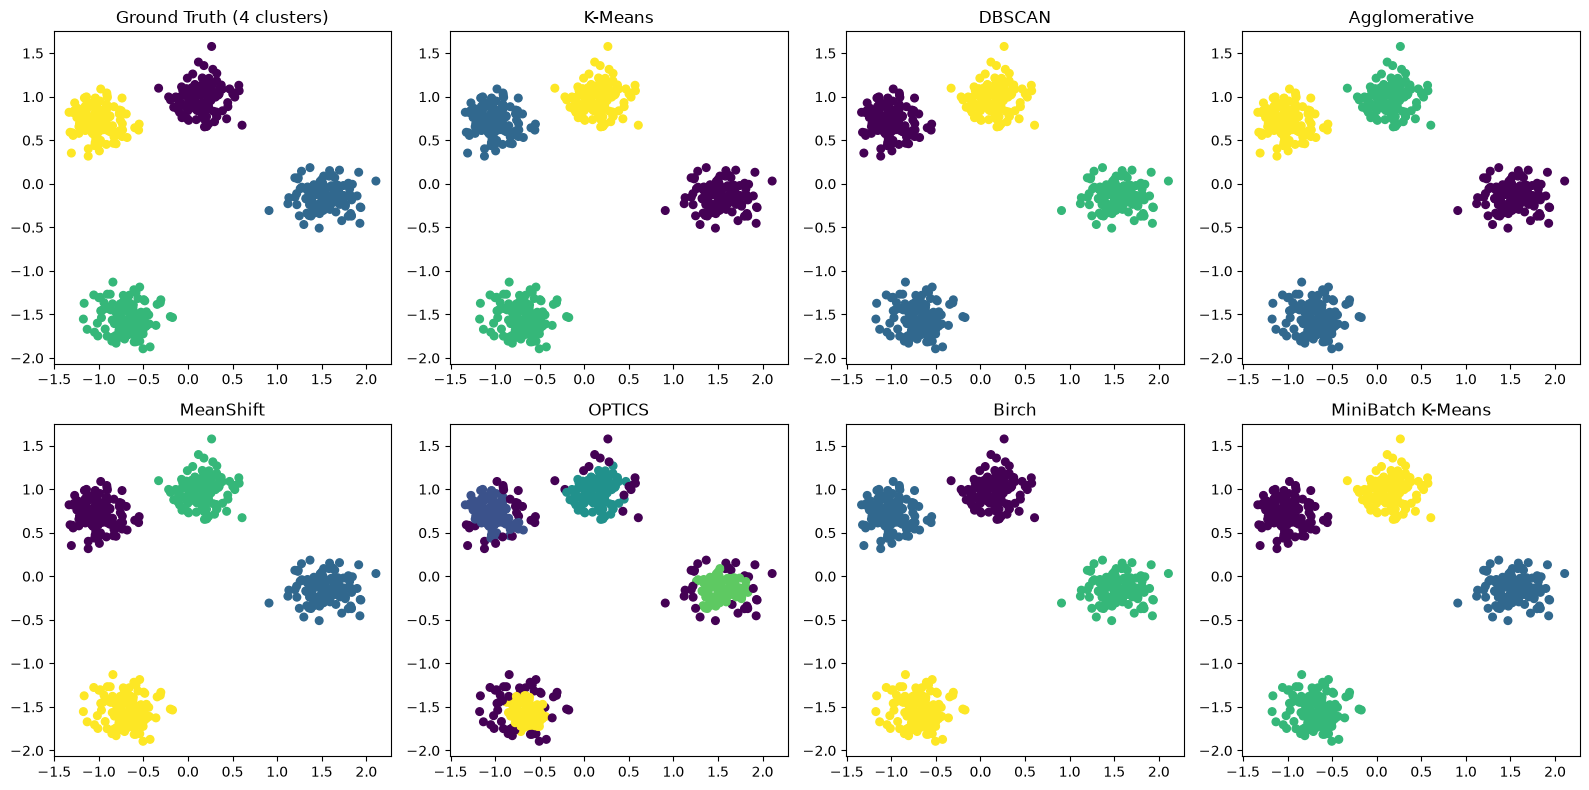

In [6]:
print("\n" + "=" * 60)
print("STEP 3: Visualizing Clustering Results (Blobs)")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Use a subset of algorithms for plotting
plot_algorithms = ['K-Means', 'DBSCAN', 'Agglomerative', 'MeanShift', 'OPTICS', 'Birch', 'MiniBatch K-Means']
plot_idx = 0

# We'll plot blobs with ground truth first
axes[0].scatter(X_blobs_scaled[:,0], X_blobs_scaled[:,1], c=y_blobs, cmap='viridis', s=30)
axes[0].set_title('Ground Truth (4 clusters)')

for i, name in enumerate(plot_algorithms):
    if name in algorithms:
        labels = results[('Blobs', name)]
        axes[i+1].scatter(X_blobs_scaled[:,0], X_blobs_scaled[:,1], c=labels, cmap='viridis', s=30)
        axes[i+1].set_title(name)

plt.tight_layout()
plt.show()


## 6. Compare algorithms on both datasets


In [7]:
print("\n" + "=" * 60)
print("STEP 4: Summary of Silhouette Scores")
print("=" * 60)

summary = []
for (ds, name), labels in results.items():
    if len(set(labels)) > 1:
        sil = silhouette_score(datasets[ds], labels)
        summary.append({'Dataset': ds, 'Algorithm': name, 'Silhouette': sil})

df_summary = pd.DataFrame(summary)
pivot = df_summary.pivot(index='Algorithm', columns='Dataset', values='Silhouette')
print(pivot.round(4))



STEP 4: Summary of Silhouette Scores
Dataset             Blobs   Moons
Algorithm                        
Agglomerative      0.7979  0.3946
Birch              0.7979  0.3927
DBSCAN             0.7979  0.3860
K-Means            0.7979  0.4280
MeanShift          0.7979  0.4662
MiniBatch K-Means  0.7979  0.4179
OPTICS             0.4322  0.1148


## 7. Final observations


In [8]:
print("\n" + "=" * 60)
print("📊 Mini Project Complete!")
print("=" * 60)
print("Clustering techniques covered:")
print(" ✅ K-Means")
print(" ✅ MiniBatch K-Means")
print(" ✅ DBSCAN")
print(" ✅ Agglomerative Clustering")
print(" ✅ MeanShift")
print(" ✅ OPTICS")
print(" ✅ Birch")
print(" ✅ Evaluation metrics: Silhouette, Calinski-Harabasz, Davies-Bouldin")
print("\nObservations:")
print("- K-Means and its variants work well on spherical blobs but fail on moons.")
print("- DBSCAN and OPTICS can capture non-linear shapes like moons.")
print("- Agglomerative clustering (with appropriate linkage) can also work.")
print("- MeanShift requires bandwidth tuning; it may over‑ or under‑segment.")
print("- Birch is fast on large datasets but assumes spherical clusters.")
print("- Evaluation metrics help quantify quality; Silhouette is most interpretable.")


📊 Mini Project Complete!
Clustering techniques covered:
 ✅ K-Means
 ✅ MiniBatch K-Means
 ✅ DBSCAN
 ✅ Agglomerative Clustering
 ✅ MeanShift
 ✅ OPTICS
 ✅ Birch
 ✅ Evaluation metrics: Silhouette, Calinski-Harabasz, Davies-Bouldin

Observations:
- K-Means and its variants work well on spherical blobs but fail on moons.
- DBSCAN and OPTICS can capture non-linear shapes like moons.
- Agglomerative clustering (with appropriate linkage) can also work.
- MeanShift requires bandwidth tuning; it may over‑ or under‑segment.
- Birch is fast on large datasets but assumes spherical clusters.
- Evaluation metrics help quantify quality; Silhouette is most interpretable.
